In [2]:
import pandas as pd

import numpy as np
from matplotlib import pyplot



In [4]:


# Carga del dataset
df = pd.read_csv('bike-sharing-demand/train.csv')

# Dimensiones generales
print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


# Primeras 5 filas con todas las columnas
print("\nPrimeras 5 filas:")
print(df.head())

# Tipos de datos y valores nulos
print("\nInformación del dataset:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())


Filas:    10886
Columnas: 12

Primeras 5 filas:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

Información del dataset:
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp        

In [ ]:
# Convertir datetime una sola vez y guardarla como objeto fecha
dt = pd.to_datetime(df['datetime'])

# Extraer componentes temporales útiles
df['hour']      = dt.dt.hour        # hora del día (0-23)
df['month']     = dt.dt.month       # mes del año (1-12)
df['dayofweek'] = dt.dt.dayofweek   # día de la semana (0=lunes, 6=domingo)

# Eliminar columnas que no sirven
df = df.drop(columns=['datetime', 'casual', 'registered'])

# Verificar resultado
print(f"Columnas después del preprocesamiento: {df.shape[1]}")
print(f"\nColumnas actuales:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
print(df.head())


Columnas después del preprocesamiento: 12

Columnas actuales:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'hour', 'month', 'dayofweek']

Primeras 5 filas:
   season  holiday  workingday  weather  temp   atemp  humidity  windspeed  \
0       1        0           0        1  9.84  14.395        81        0.0   
1       1        0           0        1  9.02  13.635        80        0.0   
2       1        0           0        1  9.02  13.635        80        0.0   
3       1        0           0        1  9.84  14.395        75        0.0   
4       1        0           0        1  9.84  14.395        75        0.0   

   count  hour  month  dayofweek  
0     16     0      1          5  
1     40     1      1          5  
2     32     2      1          5  
3     13     3      1          5  
4      1     4      1          5  

Estadísticas de 'count':
count    10886.000000
mean       191.574132
std        181.144454
min          1.00000

In [7]:

# Separar características (X) y variable objetivo (y)
y = df['count'].values

# X = features (todo excepto count)
X = df.drop(columns=['count']).values

m, n = X.shape

# Verificar dimensiones
print(f"Ejemplos de entrenamiento (m): {m}")
print(f"Features (n):                  {n}")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Ejemplos de entrenamiento (m): 10886
Features (n):                  11
Dimensiones de X: (10886, 11)
Dimensiones de y: (10886,)


In [8]:
# NORMALIZACIÓN DE CARACTERÍSTICAS
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [1]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

NameError: name 'featureNormalize' is not defined

In [10]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [11]:
print(X)

[[ 1.         -1.34986372 -0.17149048 ... -1.66894356 -1.60312148
   0.99079257]
 [ 1.         -1.34986372 -0.17149048 ... -1.52434128 -1.60312148
   0.99079257]
 [ 1.         -1.34986372 -0.17149048 ... -1.379739   -1.60312148
   0.99079257]
 ...
 [ 1.          1.33801198 -0.17149048 ...  1.36770431  1.59063939
  -0.50584498]
 [ 1.          1.33801198 -0.17149048 ...  1.51230659  1.59063939
  -0.50584498]
 [ 1.          1.33801198 -0.17149048 ...  1.65690887  1.59063939
  -0.50584498]]


In [ ]:
#Función de costo para rml
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [ ]:
#Función de descenso por el gradiente para rml
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

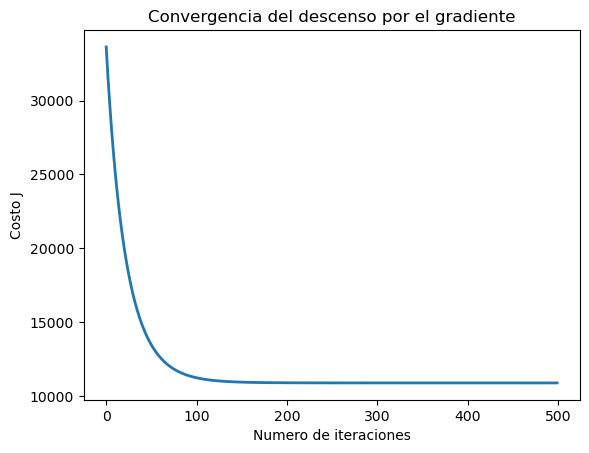

In [23]:
# ENTRENAMIENTO
alpha = 0.02
num_iters = 500

# Inicializa theta (1 bias + 9 features)
theta = np.zeros(10)

# Ejecuta el descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por el gradiente')
pyplot.show()



In [ ]:
#PREDICCIONES
# 5 ejemplos de horas con diferentes condiciones
ejemplos = [
    # [bias, season, holiday, workingday, weather, temp, atemp, humidity, windspeed, hour]
    [1, 2, 0, 1, 1, 28, 31, 55, 10, 8],   # verano, día laboral, mañana, buen clima
    [1, 1, 0, 1, 2, 10, 12, 75, 20, 17],  # primavera, día laboral, tarde, nublado
    [1, 3, 1, 0, 1, 22, 25, 60, 8,  14],  # otoño, feriado, mediodía, buen clima
    [1, 4, 0, 0, 3, 5,  6,  90, 30, 2],   # invierno, fin de semana, madrugada, lluvia
    [1, 2, 0, 1, 1, 30, 33, 45, 5,  18],  # verano, día laboral, hora pico, buen clima
]

print("=" * 60)
print(f"{'Ejemplo':>8} {'Condición':>25} {'Predicción':>12}")
print("=" * 60)

condiciones = [
    'Verano mañana laboral',
    'Primavera tarde nublado',
    'Otoño feriado mediodía',
    'Invierno madrugada lluvia',
    'Verano hora pico laboral'
]

for i, (ejemplo, condicion) in enumerate(zip(ejemplos, condiciones)):
    X_array = np.array(ejemplo, dtype=float)
    X_array[1:] = (X_array[1:] - mu) / sigma
    pred = max(0,np.dot(X_array, theta))
    print(f"{i+1:>8} {condicion:>25} {pred:>10.0f} bicicletas")

print("=" * 60)


 Ejemplo                 Condición   Predicción
       1     Verano mañana laboral        221 bicicletas
       2   Primavera tarde nublado         98 bicicletas
       3    Otoño feriado mediodía        227 bicicletas
       4 Invierno madrugada lluvia          0 bicicletas
       5  Verano hora pico laboral        331 bicicletas
